In [10]:
from gradcam import GradCAM
import torch
from torchvision import models, transforms
from PIL import Image
from gradcam.utils import visualize_cam
from gradcam import GradCAM, GradCAMpp
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image
import torch.nn as nn

import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"
CUDA_VISIBLE_DEVICES=1
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

In [11]:
image_name = "9157384_r"
image_path = f"/home/feg48/kl_grading_project/xray/data/cropped_data/test/1/{image_name}.jpg"
img = Image.open(image_path).convert('RGB')

torch_img = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])(img).to(device)
normed_torch_img = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(torch_img)[None]


In [ ]:
resnet_model = models.resnet18(pretrained=False)
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = torch.nn.Linear(num_ftrs, 2)

pretrained_weights = torch.load("../model/resnet_best.pth", map_location='cpu')
new_state_dict = {}
for k, v in pretrained_weights.items():
    k = k.replace("module.", "")
    new_state_dict[k] = v
resnet_model.load_state_dict(new_state_dict)


<All keys matched successfully>

In [ ]:
from networks.resnet_big import SupConResNet, LinearClassifier
import torch.backends.cudnn as cudnn

def get_model(model_path_folder):
    model = SupConResNet(name='resnet18')
    criterion = torch.nn.CrossEntropyLoss()

    classifier = LinearClassifier(name='resnet18', num_classes=2)

    model_path = f'save/SupCon/path_models/{model_path_folder}/best_model.pth'
    classifier_path = f'save/SupCon/path_models/{model_path_folder}/best_classifier.pth'

    model_ckpt = torch.load(model_path, map_location='cpu')
    model_state_dict = model_ckpt['model']
    new_model_state_dict = {}
    for k, v in model_state_dict.items():
        k = k.replace("module.", "")
        new_model_state_dict[k] = v
    model_state_dict = new_model_state_dict

    classifier_ckpt = torch.load(classifier_path, map_location='cpu')
    classifier_state_dict = classifier_ckpt['model']
    new_classifier_state_dict = {}
    for k, v in classifier_state_dict.items():
        k = k.replace("module.", "")
        new_classifier_state_dict[k] = v
    classifier_state_dict = new_classifier_state_dict

    model = model.cuda()
    classifier = classifier.cuda()
    criterion = criterion.cuda()
    cudnn.benchmark = True

    model.load_state_dict(model_state_dict)
    classifier.load_state_dict(classifier_state_dict)

    return model, classifier


In [ ]:
class CombinedModel(nn.Module):
    def __init__(self, model, classifier):
        super(CombinedModel, self).__init__()
        self.encoder = model.encoder  # Use the encoder part of the original model
        self.classifier = classifier  # Attach the classifier to the encoder

    def forward(self, x):
        features = self.encoder(x)  # Get features from the encoder
        output = self.classifier(features)  # Pass features through the classifier
        return output

# Create the combined model
simclr_path = 'SimCLR_Linear_path'
simclr_m, simclr_c = get_model(simclr_path)
simclr_model = CombinedModel(simclr_m, simclr_c)


supcon_path = 'SupCon_Linear_path'
supcon_m, supcon_c = get_model(supcon_path)
supcon_model = CombinedModel(supcon_m, supcon_c)


ascon_path = 'XASSupCon_path'
ascon_m, ascon_c = get_model(ascon_path)
ascon_model = CombinedModel(ascon_m, ascon_c)

In [16]:
configs = [
    # dict(model_type='alexnet', arch=alexnet, layer_name='features_11'),
    # dict(model_type='vgg', arch=vgg, layer_name='features_29'),
    dict(model_type='resnet', arch=resnet_model, target_layer=resnet_model.layer4[-1]),
    dict(model_type='resnet', arch=simclr_model, target_layer=simclr_model.encoder.layer4[-1]),
    dict(model_type='resnet', arch=supcon_model, target_layer=supcon_model.encoder.layer4[-1]),
    dict(model_type='resnet', arch=ascon_model, target_layer=ascon_model.encoder.layer4[-1]),
    # dict(model_type='squeezenet', arch=squeezenet, layer_name='features_12_expand3x3_activation')
]


for config in configs:
    config['arch'].to(device).eval()

cams = [
    [cls(arch=config['arch'], target_layer=config['target_layer']) for cls in (GradCAM, GradCAMpp)]
    for config in configs
]

In [17]:
images = []
for gradcam, gradcam_pp in cams:
    mask, _ = gradcam(normed_torch_img, class_idx=1)
    heatmap, result = visualize_cam(mask, torch_img)

    mask_pp, _ = gradcam_pp(normed_torch_img, class_idx=1)
    heatmap_pp, result_pp = visualize_cam(mask_pp, torch_img)
    
    # images.extend([torch_img.cpu(), heatmap, heatmap_pp, result, result_pp])
    images.extend([torch_img.cpu(), result_pp])
    
grid_image = make_grid(images, nrow=5)

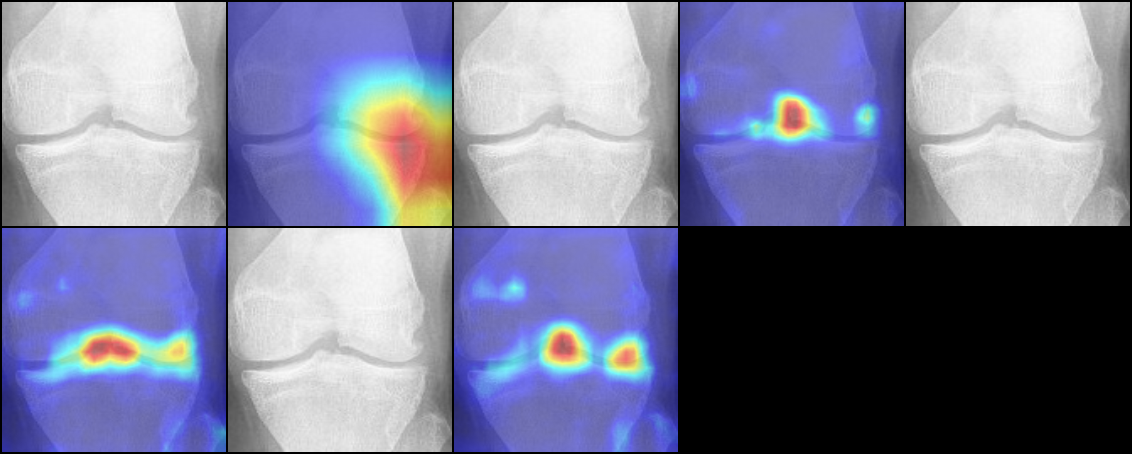

In [8]:
transforms.ToPILImage()(grid_image)